<a href="https://colab.research.google.com/github/aot-abhishekyadav/Machine-Learning-Fundamentals/blob/main/18-KnnImputer/knn_imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A KNN Imputer (K-Nearest Neighbors Imputer) is a technique for filling in missing values in a dataset by using the values of the k most similar observations (neighbors).

### How it works

1. Identify rows with missing values.

2. Compute the distance (usually Euclidean) between the incomplete row and other rows using the available (non-missing) features.

3. Find the k nearest neighbors.

4. Impute the missing value using:


Mean of the neighbors' values (for numerical data, most common).

Weighted mean if distance weighting is used.

Mode for categorical variables (in some implementations).

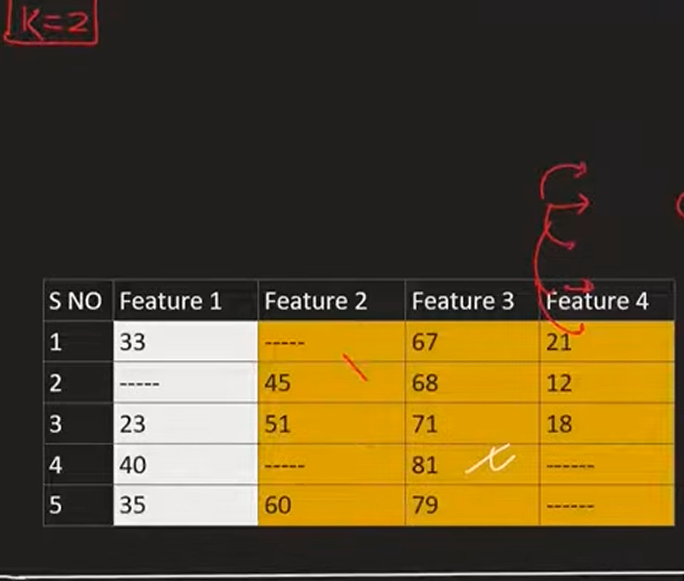

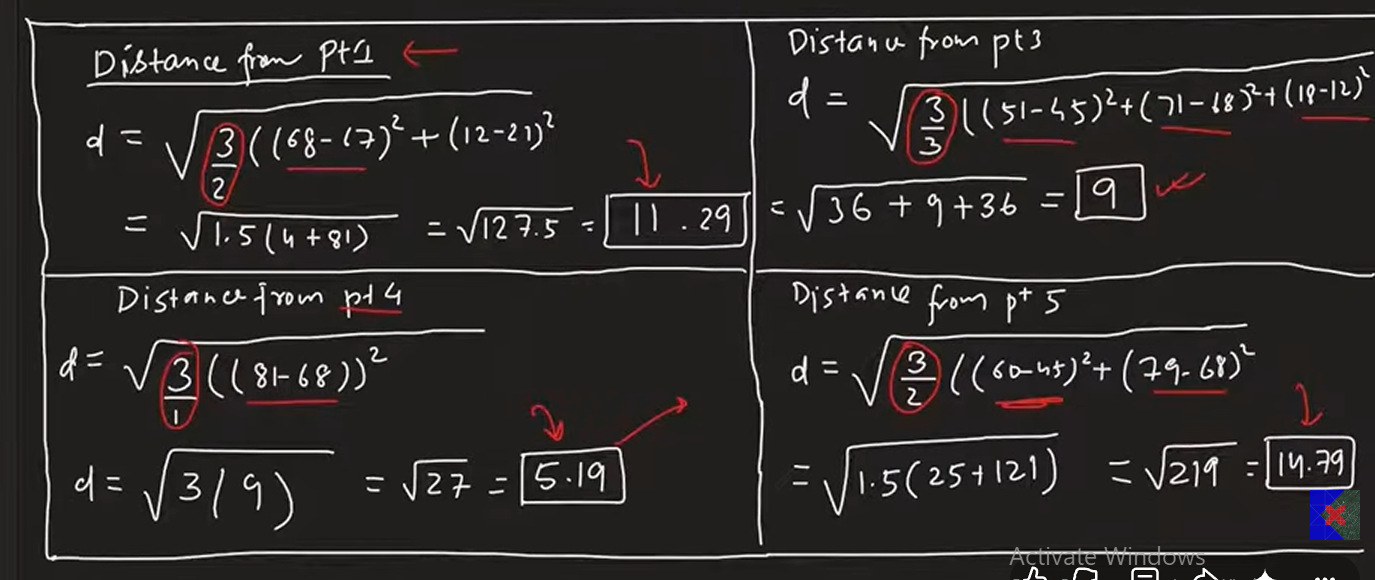

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Titanic1.csv', usecols=['Age', 'Pclass', 'Fare', 'Survived'])

In [ ]:
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Age,177
Fare,0


In [ ]:
df.isnull().mean() * 100

,0
Survived,0.00000
Pclass,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
X_train.head()

,Pclass,Age,Fare
30,1,40.0,27.7208
10,3,4.0,16.7000
873,3,47.0,9.0000
182,3,9.0,31.3875
876,3,20.0,9.8458


In [ ]:
knn = KNNImputer(n_neighbors= 3, weights='distance')

In [ ]:
X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train_trf,y_train)

y_pred = lr.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.7039106145251397

In [ ]:
# Comparision with Simple Imputer --> mean

si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train_trf2,y_train)

y_pred2 = lr.predict(X_test_trf2)

accuracy_score(y_test,y_pred2)

0.6927374301675978

In [ ]:
pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('classifier', LogisticRegression(max_iter=1000))
])

param_grid = {
    'imputer__n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'imputer__weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'imputer__n_neighbors': 2, 'imputer__weights': 'distance'}
Best Score: 0.7078400472766669
Test Accuracy: 0.7094972067039106
